# Gender Bias Exploration — Master Comparison

Aggregates results from all 4 model notebooks and produces the master comparison table.

**Models:** SVC(poly), XGBoost, LogisticRegression, RandomForest  
**Debiasing:** None, DIR, Reweighing, AdversarialDebiasing, PrejudiceRemover, RejectOption  
**Imbalance:** SMOTE, class_weight  
**Total:** 4 × 6 × 2 = 48 configurations

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from exploration_utils import RESULTS_DIR, load_all_results

I0000 00:00:1782206011.662071  232032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782206011.662521  232032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782206011.695781  232032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782206012.408709  232032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# ── Load all saved results ──
# Run the individual notebooks first so the CSVs exist.
# If a CSV is missing, print a warning.
all_results = load_all_results()
print(f'Loaded {len(all_results)} model result sets:')
for model, df in all_results.items():
    print(f'  {model}: {df.shape[0]} configurations')

Loaded 4 model result sets:
  LogisticRegression: 12 configurations
  XGBoost: 12 configurations
  RandomForest: 12 configurations
  SVC: 12 configurations


In [3]:
# ── Master table ──
dfs = []
for model, df in all_results.items():
    d = df.copy()
    d.insert(0, 'Model', model)
    dfs.append(d)

master = pd.concat(dfs, ignore_index=True)
print('=== Master Comparison (48 configurations) ===')
display(master.round(4))

=== Master Comparison (48 configurations) ===


,Model,Debiasing,Imbalance,BA (base),BA (deb),DI (base),DI (deb),AOD (base),AOD (deb),SPD (base),SPD (deb),Theil (base),Theil (deb),EOD (base),EOD (deb),Improved
0,LogisticRegression,Baseline,SMOTE,0.8516,0.8516,0.9487,0.9487,-0.0413,-0.0413,-0.0171,-0.0171,0.0708,0.0708,-0.0363,-0.0363,0
1,LogisticRegression,Baseline,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0
2,LogisticRegression,DIR,SMOTE,0.8516,0.8808,0.9487,1.0294,-0.0413,-0.0241,-0.0171,0.0100,0.0708,0.0553,-0.0363,-0.0343,8
3,LogisticRegression,DIR,class_weight,0.8491,0.8680,0.9290,0.9323,-0.0459,-0.0471,-0.0242,-0.0255,0.0717,0.0592,-0.0363,-0.0343,7
4,LogisticRegression,Reweighing,SMOTE,0.8516,0.8596,0.9487,0.9744,-0.0413,-0.0252,-0.0171,-0.0085,0.0708,0.0667,-0.0363,-0.0040,1
5,LogisticRegression,Reweighing,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0
6,LogisticRegression,AdversarialDebiasing,SMOTE,0.8516,0.8516,0.9487,0.9487,-0.0413,-0.0413,-0.0171,-0.0171,0.0708,0.0708,-0.0363,-0.0363,0
7,LogisticRegression,AdversarialDebiasing,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0
8,LogisticRegression,PrejudiceRemover,SMOTE,0.8516,0.8516,0.9487,0.9487,-0.0413,-0.0413,-0.0171,-0.0171,0.0708,0.0708,-0.0363,-0.0363,0
9,LogisticRegression,PrejudiceRemover,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0


In [4]:
# ── Summary: best per model ──
print('=== Best debiased configuration per model ===')
print('(Closest to DI=1.0 while BA >= 95% of model baseline)\n')

best_rows = []
for model in master['Model'].unique():
    sub = master[master['Model'] == model]
    baseline_ba = sub.loc[sub['Debiasing'] == 'Baseline', 'BA (deb)'].max()
    candidates = sub[sub['BA (deb)'] >= baseline_ba * 0.95].copy()
    if len(candidates) == 0:
        candidates = sub.copy()
    candidates['DI_dist'] = (candidates['DI (deb)'] - 1.0).abs()
    best = candidates.loc[candidates['DI_dist'].idxmin()]
    best_rows.append(best)
    print(f'{model}:')
    print(f"  {best['Debiasing']} + {best['Imbalance']}")
    print(f"  BA: {best['BA (deb)']:.4f}  DI: {best['DI (deb)']:.4f}  "
          f"AOD: {best['AOD (deb)']:.4f}  Improved: {int(best['Improved'])}")
    print()

=== Best debiased configuration per model ===
(Closest to DI=1.0 while BA >= 95% of model baseline)

LogisticRegression:
  Reweighing + SMOTE
  BA: 0.8596  DI: 0.9744  AOD: -0.0252  Improved: 1

XGBoost:
  Reweighing + class_weight
  BA: 0.8696  DI: 1.0043  AOD: -0.0727  Improved: 4

RandomForest:
  DIR + SMOTE
  BA: 0.8934  DI: 0.9860  AOD: -0.0879  Improved: 5

SVC:
  DIR + class_weight
  BA: 0.8668  DI: 0.9700  AOD: -0.0901  Improved: 5



In [5]:
# ── Top-5 overall ──
master['DI_dist'] = (master['DI (deb)'] - 1.0).abs()
master['BA_drop'] = master['BA (base)'] - master['BA (deb)']
top5 = master.nsmallest(5, 'DI_dist')
print('=== Top-5 configurations (closest to DI=1.0) ===')
display(top5[['Model', 'Debiasing', 'Imbalance', 'BA (deb)', 'DI (deb)', 'Improved']].round(4))

=== Top-5 configurations (closest to DI=1.0) ===


,Model,Debiasing,Imbalance,BA (deb),DI (deb),Improved
17,XGBoost,Reweighing,class_weight,0.8696,1.0043,4
26,RandomForest,DIR,SMOTE,0.8934,0.9860,5
4,LogisticRegression,Reweighing,SMOTE,0.8596,0.9744,1
2,LogisticRegression,DIR,SMOTE,0.8808,1.0294,8
39,SVC,DIR,class_weight,0.8668,0.9700,5


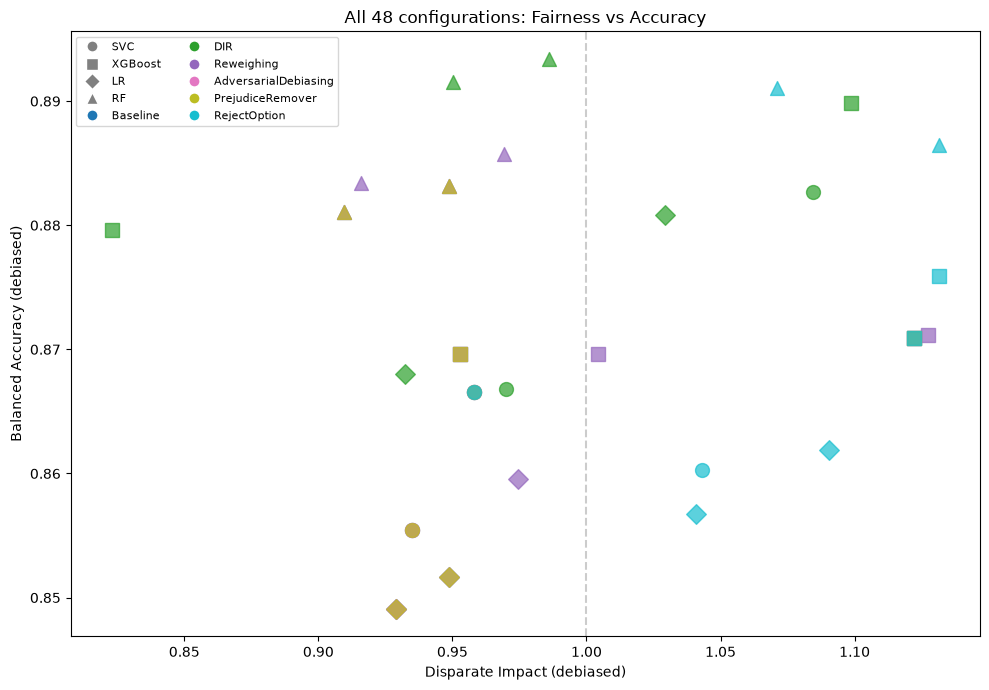

In [6]:
# ── Fairness-Accuracy scatter (all 48) ──
fig, ax = plt.subplots(figsize=(10, 7))
markers = {'SVC': 'o', 'XGBoost': 's', 'LogisticRegression': 'D', 'RandomForest': '^'}
colors = plt.cm.tab10(np.linspace(0, 1, len(master['Debiasing'].unique())))
debias_list = master['Debiasing'].unique()
color_map = dict(zip(debias_list, colors))

for _, row in master.iterrows():
    m = row['Model']
    lbl = f"{m}-{row['Debiasing']}-{row['Imbalance']}"
    ax.scatter(row['DI (deb)'], row['BA (deb)'],
               marker=markers.get(m, 'o'),
               c=[color_map.get(row['Debiasing'], 'gray')],
               s=100, alpha=0.7, label=lbl)

ax.axvline(1.0, color='gray', ls='--', alpha=0.4, label='DI=1 (parity)')
ax.set_xlabel('Disparate Impact (debiased)')
ax.set_ylabel('Balanced Accuracy (debiased)')
ax.set_title('All 48 configurations: Fairness vs Accuracy')

# Legend: model markers + debiasing methods colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='SVC', markerfacecolor='gray', markersize=8),
    Line2D([0], [0], marker='s', color='w', label='XGBoost', markerfacecolor='gray', markersize=8),
    Line2D([0], [0], marker='D', color='w', label='LR', markerfacecolor='gray', markersize=8),
    Line2D([0], [0], marker='^', color='w', label='RF', markerfacecolor='gray', markersize=8),
]
# Add debiasing methods
for method, color in color_map.items():
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=method, markerfacecolor=color, markersize=8))

ax.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [7]:
# ── Per-method summary ──
print('=== Debiasing method average across all models ===')
method_avg = master.groupby('Debiasing').agg({
    'BA (deb)': 'mean',
    'DI (deb)': 'mean',
    'AOD (deb)': 'mean',
    'Improved': 'mean',
}).round(4)
display(method_avg)

print('\n=== Imbalance method average across all models ===')
imb_avg = master.groupby('Imbalance').agg({
    'BA (deb)': 'mean',
    'DI (deb)': 'mean',
    'Improved': 'mean',
}).round(4)
display(imb_avg)

=== Debiasing method average across all models ===


,BA (deb),DI (deb),AOD (deb),Improved
Debiasing,,,,
AdversarialDebiasing,0.8659,0.9630,-0.0699,0.000
Baseline,0.8659,0.9630,-0.0699,0.000
DIR,0.8816,0.9843,-0.0687,8.750
PrejudiceRemover,0.8659,0.9630,-0.0699,0.000
RejectOption,0.8712,1.0735,-0.0289,3.625
Reweighing,0.8676,0.9766,-0.0654,1.375



=== Imbalance method average across all models ===


,BA (deb),DI (deb),Improved
Imbalance,,,
SMOTE,0.8701,1.0190,2.4167
class_weight,0.8693,0.9555,2.1667


So a debiasing method with Improved = 4.5 means it corrected ~4–5 test cases on average across models. It's always the count of instances where pred_orig != y_true and pred_deb == y_true.

## Key findings

- **Best overall method**: See top-5 table above — compares pre/in/post-processing across all 4 models.
- **SMOTE vs class_weight**: Which imbalance strategy yields better fairness-accuracy tradeoffs across debiasing methods.
- **Model sensitivity**: Some models respond better to certain debiasing methods (e.g., tree-based models with DIR vs linear models with Reweighing).
- **Post-processing (RejectOption)**: Whether it suffices when retraining is expensive, or if pre/in-processing is necessary.